In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt 

import portfolio
import market_data
import models
import simulation
import risk_measure

# import arch

import importlib

my_modules = [portfolio, market_data, models, simulation, risk_measure]

for module in  my_modules:
    importlib.reload(module)


[*********************100%***********************]  2 of 2 completed


<Axes: xlabel='Date'>

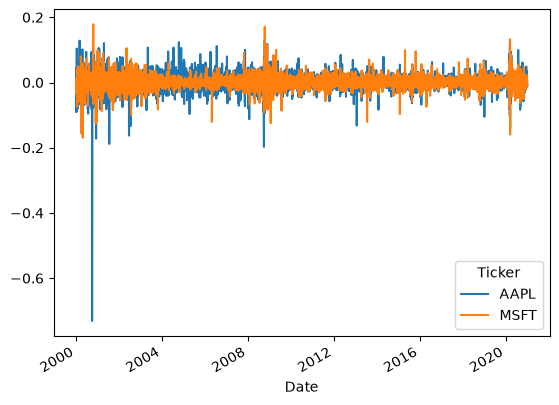

In [170]:
port = portfolio.Portfolio(
    holdings={
        "MSFT": 2,
        "AAPL": 3
    }
)

data = market_data.MarketData.from_yfinance(
    port.assets,
    "2000-01-01",
    "2021-01-01",
)

risk_factors = port.risk_factors(data)
risk_factors.plot()

In [171]:
ewma = models.multivariate_ewma_covariance_estimator(
    risk_factors
)

print(port.weights(data))

print(type(ewma.covariances))
print(models.multivariate_ewma_forecast(risk_factors,ewma))
# risk_factors.plot()
# (2*np.sqrt(ewma.covariances)).plot()
# (-2*np.sqrt(ewma.covariances)).plot()

                AAPL      MSFT
Date                          
2000-01-03  0.034273  0.965727
2000-01-04  0.032539  0.967461
2000-01-05  0.032666  0.967334
2000-01-06  0.030929  0.969071
2000-01-07  0.031943  0.968057
...              ...       ...
2020-12-24  0.475018  0.524982
2020-12-28  0.481323  0.518677
2020-12-29  0.478878  0.521122
2020-12-30  0.479506  0.520494
2020-12-31  0.476745  0.523255

[5284 rows x 2 columns]
<class 'numpy.ndarray'>
Ticker      AAPL      MSFT
Ticker                    
AAPL    0.000406  0.000172
MSFT    0.000172  0.000203


In [172]:
garch1_1 = models.fit_garch(risk_factors)

ValueError: Univariate GARCH requires exactly one risk factor.

In [ ]:

print("GARCH(1,1) model:", "\n", garch1_1.summary(), "\n")

GARCH(1,1) model: 
                        Zero Mean - GARCH Model Results                        
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7292.25
Distribution:                  Normal   AIC:                           14590.5
Method:            Maximum Likelihood   BIC:                           14610.2
                                        No. Observations:                 5283
Date:                Fri, Sep 18 2026   Df Residuals:                     5283
Time:                        11:06:57   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0225  4.966e-03      

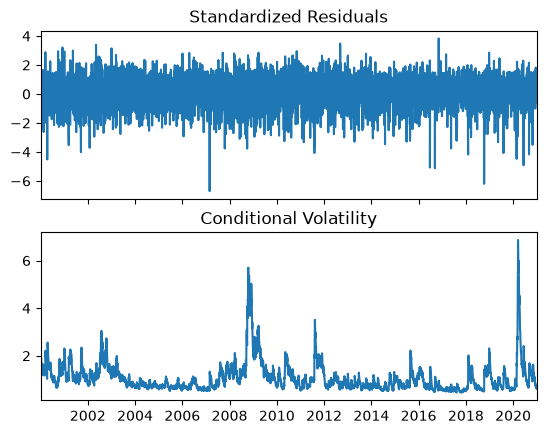

In [ ]:
garch1_1.plot()
plt.show()
plt.close()

Date
2000-01-04    0.000263
2000-01-05    0.000414
2000-01-06    0.000360
2000-01-07    0.000313
2000-01-10    0.000358
                ...   
2020-12-24    0.000042
2020-12-28    0.000040
2020-12-29    0.000046
2020-12-30    0.000042
2020-12-31    0.000039
Name: ^GSPC, Length: 5283, dtype: float64


<Axes: xlabel='Date'>

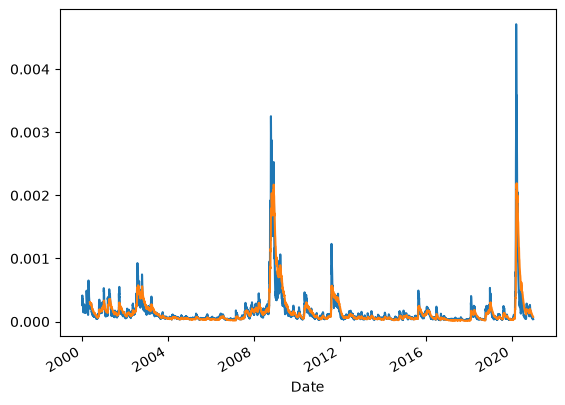

In [ ]:
garch1_1_cond_var = (models.garch_conditional_variance(garch1_1).variances)
print(garch1_1_cond_var)
garch1_1_cond_var.plot()
(ewma.variances).plot()

In [ ]:
# print(models.garch_forecast(garch1_1))
# print(models.ewma_forecast(risk_factors,ewma))
# ewma.variances
# risk_factors.index[-1]
# type(garch1_1.model.distribution)
# print((risk_factors)["^GSPC"], ewma.variances)
print(risk_factors.squeeze().div(np.sqrt(ewma.variances)))

Date
2000-01-04         NaN
2000-01-05         NaN
2000-01-06         NaN
2000-01-07         NaN
2000-01-10         NaN
                ...   
2020-12-24    0.384732
2020-12-28    0.962998
2020-12-29   -0.247617
2020-12-30    0.151750
2020-12-31         NaN
Name: ^GSPC, Length: 5283, dtype: float64


In [ ]:
import arch
# arch.univariate.Normal().parameter_names()

0.01   -2.326348
0.05   -1.644854
Name: quantile, dtype: float64
                  1%        5%
Date                          
2000-01-04  0.037692  0.026650
2000-01-05  0.047312  0.033452
2000-01-06  0.044116  0.031192
2000-01-07  0.041136  0.029085
2000-01-10  0.044044  0.031142
...              ...       ...
2020-12-24  0.015028  0.010626
2020-12-28  0.014669  0.010372
2020-12-29  0.015723  0.011117
2020-12-30  0.015124  0.010693
2020-12-31  0.014516  0.010263

[5283 rows x 2 columns]


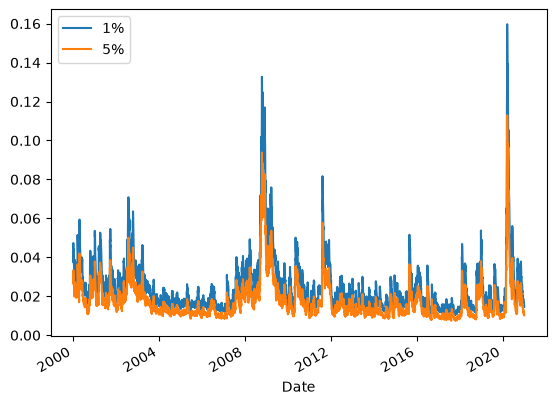

In [ ]:
q = simulation.parametric_quantiles(garch1_1,[0.01,0.05])
print(q)

VaR = risk_measure.parametric_value_at_risk(garch1_1_cond_var,q)
print(VaR)
# risk_factors.plot()
VaR.plot()
plt.show()

                  1%        5%
Date                          
2000-01-04  0.043182  0.033421
2000-01-05  0.054204  0.041951
2000-01-06  0.050542  0.039116
2000-01-07  0.047128  0.036474
2000-01-10  0.050460  0.039053
...              ...       ...
2020-12-24  0.017217  0.013325
2020-12-28  0.016806  0.013007
2020-12-29  0.018013  0.013941
2020-12-30  0.017327  0.013410
2020-12-31  0.016630  0.012871

[5283 rows x 2 columns]


<Axes: xlabel='Date'>

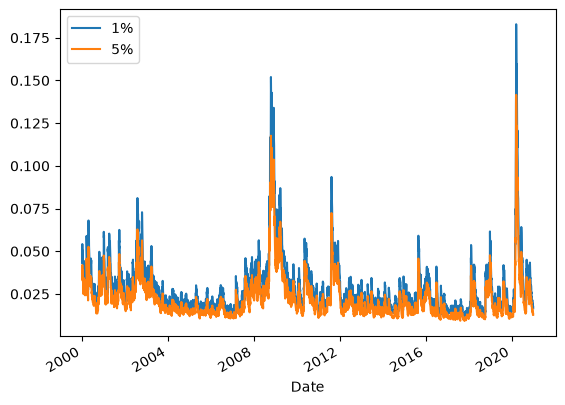

In [ ]:
tail_means=simulation.parametric_tail_means(garch1_1,[0.01,0.05])
Es=risk_measure.expected_shortfall(garch1_1_cond_var,tail_means)
print(Es)
Es.plot()


In [ ]:
portBT = portfolio.Portfolio(
    holdings={
        "^GSPC": 1,
    }
)

dataBT = market_data.MarketData.from_yfinance(
    portBT.assets,
    "2000-01-01",
    "2020-12-31",
    # "2000-12-31",
)

risk_factorsBT = portBT.risk_factors(dataBT)



estimation_window_length = 500
testing_window_length = len(risk_factorsBT) 

for t in range(estimation_window_length, testing_window_length-1):

    t1  = t - estimation_window_length 
    t2 =  t 

    window = risk_factorsBT.iloc[t1:t2]

    # EMWA

    ewmaBT = models.univariate_ewma_variance_estimator(window)
    variance_t = models.ewma_forecast(window,ewmaBT)
    q=simulation.parametric_quantiles("normal",[0.01,0.05])

    print(risk_measure.parametric_value_at_risk(variance_t,q))


    # ewmaBT.append(
    # ewmaBT.append(models.univariate_ewma_variance_estimator(window))<
    # sigma_t_ewma =  (models.univariate_ewma_variance_estimator(window).variances).iloc[t-1]
    # ewma_covar_forecast = 0.96 *  sigma_t_ewma + (1 - 0.96) * risk_factors.iloc[t]  # Write a fucntion for this !!!!!
    # )




[*********************100%***********************]  1 of 1 completed


5282
                  1%        5%
2002-01-02  0.023688  0.016749
                  1%        5%
2002-01-03  0.023595  0.016683
                  1%        5%
2002-01-04  0.023298  0.016473
                  1%        5%
2002-01-07  0.023028  0.016282
                  1%        5%
2002-01-08  0.022624  0.015997
                 1%        5%
2002-01-09  0.02228  0.015753
                  1%       5%
2002-01-10  0.021837  0.01544
                  1%        5%
2002-01-11  0.021849  0.015448
                  1%        5%
2002-01-14  0.021607  0.015277
                  1%        5%
2002-01-15  0.021406  0.015135
                  1%        5%
2002-01-16  0.022315  0.015778
                  1%        5%
2002-01-17  0.022352  0.015804
                  1%        5%
2002-01-18  0.022386  0.015828
                1%        5%
2002-01-22  0.0222  0.015697
                  1%        5%
2002-01-23  0.022059  0.015597
                  1%        5%
2002-01-24  0.021675  0.015326
           